Total Vocabulary Size: 50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.0455 - loss: 3.9129
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0455 - loss: 3.9099 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0455 - loss: 3.9069
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0455 - loss: 3.9043
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0455 - loss: 3.9014
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0455 - loss: 3.8981
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0455 - loss: 3.8940
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0455 - loss: 3.8896
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0455 - loss: 3.8839
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0455 - loss: 3.8771


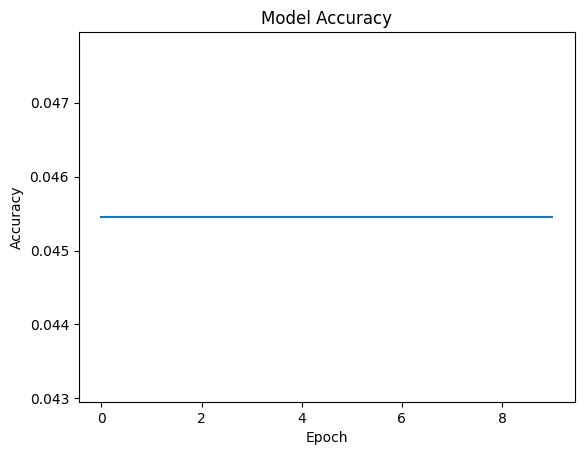

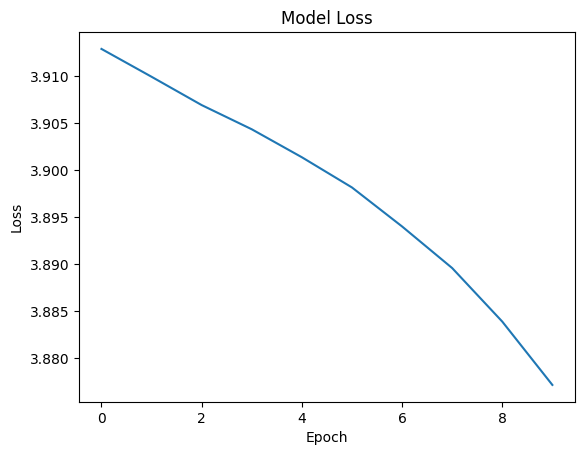


Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
cloud computing networks
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
artificial intelligence networks
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
machine learning networks
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
data engineering networks
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
big data networks


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional

data = """
cloud computing provides scalable resources
data analytics helps companies make decisions
big data technologies process massive datasets
artificial intelligence powers smart applications
machine learning improves predictive systems
neural networks recognize complex patterns
data engineering builds reliable pipelines
ai systems automate many tasks today
deep neural networks achieve high accuracy
technology innovation drives digital transformation
"""

tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

total_words = len(tokenizer.word_index) + 1

print("Total Vocabulary Size:", total_words)

input_sequences = []

for line in data.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max([len(seq) for seq in input_sequences])

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

model = Sequential()

model.add(Embedding(total_words, 64, input_length=max_sequence_len-1))

model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32)))

model.add(Dense(64, activation='relu'))
model.add(Dense(total_words, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X,
    y,
    epochs=10,
    verbose=1
)

plt.figure()
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

def predict_next_word(seed_text):

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding='pre'
    )

    predicted = np.argmax(model.predict(token_list), axis=-1)

    output_word = ""

    for word, index in tokenizer.word_index.items():
        if index == predicted:
            output_word = word
            break

    return seed_text + " " + output_word

print("\nPredictions:\n")

print(predict_next_word("cloud computing"))
print(predict_next_word("artificial intelligence"))
print(predict_next_word("machine learning"))
print(predict_next_word("data engineering"))
print(predict_next_word("big data"))